# Advanced GANs

Can we train the machine to generate the following?

1. Given the image of a criminal whose face is masked with glass. Is it possible for the machine to automatically generate the photo without glass?

2. Suppose few simple sentences which describe the bird as: “A small bird with red head. The features fade from red to gray from head to tail.” are given to machine. Is it possible for the machine to generate the image of the bird?

3. Given a photo of a person which is captured 10 years ago, is it possible for the machine to generate a photo of the same person for the present time?

Yes, advanced deep learning has made am amazing progress, where machines can be trained to generate or create new images. Deep learning models which can generate new images from the given training data set are called as Generative Adversarial Networks or in short GANs. Before understanding GANs it is required to have the knowledge of Generative models.

Difference between Discriminative and Generative models:

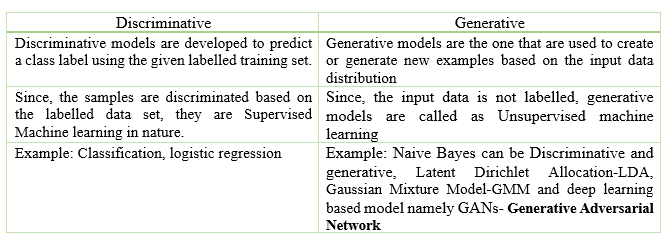

The advanced Deep learning unsupervised Generative models that are the state-of the art include: 

1) Variational Autoencoder or VAE
2) Generative Adversarial Network or GAN

## Architecture & Types

The architecture of the deep learning GAN models consists of 2 modules namely generator and Discriminator.
 1. A generator model:

    - It is the learning component of a GAN models.
    - It learns to generate the new data by incorporating the feedback received from the discriminator.
    - It learns to allow the discriminator to classify its newly generated data as real.
    Hence, training the Generator also requires the discriminator to be considered.

 2. A Discriminator models:

    - It is a classifier in GANs
    - Its job is to classify the output of the generator (newly generated data) from the real one.

![alt text](5291601008164613.jpg)

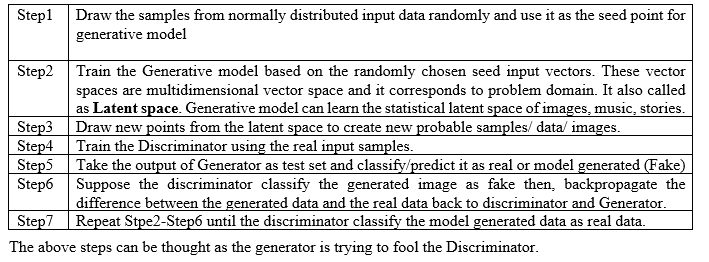

AS discussed above the generator are the pivotal for GANs. This raises a question how Generator generates the new image using the randomly chosen input space.

## Convolutional GANs

It is Deep Convolutional GANs- DCGAN which is the key technique behind the success of Generator model. Basically, generators consist of series of transpose Convolutional operations. The core idea behind the working of generator is that, it takes a random input (which can be a called as noise initially) and transforms it progressively by increasing the spatial data by decreasing the features.

[Research paper](https://arxiv.org/pdf/1406.2661.pdf)

## Spectral Normalizations

Normalization of the data is one important data preprocessing stage as it ensures the data is scaled uniformly so that, machine learning process is unbiased. Normalization is basically done through statistical transformation. Since, a GAN is a type of Deep neural network and therefore it makes sense to normalize.

One such normalization is Spectral normalization-SN. SN is used to make the deep neural network to work without collapsing. Suppose the generator generates samples with low diversity, then for every different input signal it returns same new data. So, spectral Normalization helps to deal with such problems. 

---

The application of GAN models is varied. Here two case studies are considered to demonstrate GAN for Data set generation. They are as follows:

1. Image Augmentation using MNIST data set
2. New image generation for CIFAR data Set

# Image Augmentation: Case study of GAN   

Whenever the data set don’t have enough samples to train the machine due to various constraints in data collection process then, it becomes necessary to use Augmentation. Particularly, when more complex object needs to be recognized then, Image data augmentation technique is used. It is a method of artificially escalating the size of a training dataset by creating artificially new set of images.

Using Keras Image augmentation is demonstrated by building deep learning GANs.

ImageDataGenerator class available in Keras is used in demonstration. It defines the configuration for image data preparation and augmentation.

In this demonstration following properties are demonstrated:

1. **Feature standardization**

> Using GANs model the pixel values across the entire dataset can be standardized. Feature standardization is the process of standardizing the pixel which is performed for each column in a tabular dataset. This can be done by setting the feature wise_center and feature wise_std_normalization arguments on the ImageDataGenerator class.

2. **ZCA whitening**

> Suppose the pixel has many redundant pixels then, training process can’t be effective. So, to reduce the redundant pixels whitening of an image is used. The process of transforming the original image using a linear algebra operation that reduces the redundancy in the matrix of pixel is called as Whitening transformation.

**Advantage of whitening:**
> Less redundant pixels in the image is expected to improve the structures and features in the image so that, machine can to the learn image effectively.

3. **Random flips**

> Random Flip can be used as augmentation technique on an image data to improve the performance on large and complex problems.

In [ ]:
from keras.datasets import mnist
from keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization=True)
# fit parameters from data
datagen.fit(X_train)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
  # create a grid of 3x3 images
  for i in range(0, 9):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(X_batch[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
  # show the plot
  pyplot.show()
  break

In [ ]:
# ZCA whitening
from keras.datasets import mnist
from keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(zca_whitening=True)
# fit parameters from data
datagen.fit(X_train)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
  # create a grid of 3x3 images
  for i in range(0, 9):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(X_batch[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
  # show the plot
  pyplot.show()
  break

In [ ]:
# Random Flips
from keras.datasets import mnist
from keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)
# fit parameters from data
datagen.fit(X_train)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
  # create a grid of 3x3 images
  for i in range(0, 9):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(X_batch[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
  # show the plot
  pyplot.show()
  break